# 11 — CV MC-only counting expected limits

Cosmic-veto(`spread_cosAlpha_mu_veto`)가 포함된 ABCD landing 산출물에서 SR region A의 direct-MC yield를 사용해 expected limit을 계산한다.

- Data는 읽지 않으며 observation은 background-only Asimov 값이다.
- 2mu2e, 4mu, combined 세 카드를 각 물리점마다 만든다.
- 각 process의 `sumw2`를 1-bin shape ROOT의 bin variance로 저장하고 `autoMCStats`에 전달한다.
- 이 노트북은 ABCD 추정의 최종 likelihood가 아니라 CV MC-only baseline이다.


In [1]:
from pathlib import Path
import os, re, shlex, subprocess, sys
import coffea.util
import hist
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
import pandas as pd
import uproot
import yaml
from IPython.display import display

# Coffea files produced with NumPy 2 use this module path; NumPy 1.26 uses numpy.core.
if int(np.__version__.split('.')[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault('numpy._core', _numpy_core)
    sys.modules.setdefault('numpy._core.numeric', _numpy_numeric)

BASE = Path.cwd().resolve()
if BASE.name != 'ABCD_Study':
    candidates = [BASE/'studies'/'ABCD_Study', BASE/'sidm'/'studies'/'ABCD_Study']
    BASE = next((p for p in candidates if p.is_dir()), candidates[-1])
REPOSITORY_PARENT = BASE.parents[2]
if str(REPOSITORY_PARENT) not in sys.path: sys.path.insert(0, str(REPOSITORY_PARENT))

BKG_DIR = BASE/'ABCD_landing_10ch_cosmic_veto_v1_bkg_full_merged_samples_v1'
SIGNAL_DIR = BASE/'ABCD_landing_10ch_cosmic_veto_v1_signal_full_merged_samples_v1'
SIGNAL_YAMLS = [BASE.parents[1]/'configs/ntuples/signal_2mu2e_v10.yaml',
                BASE.parents[1]/'configs/ntuples/signal_4mu_v10.yaml']
OUT = BASE/'combine_cv_mc_counting'
SHAPES, CARDS, RESULTS, PLOTS = [OUT/x for x in ('shapes','datacards','results','plots')]
CMSSW = Path(os.environ.get('COMBINE_CMSSW_BASE', '/home/cms-jovyan/CMSSW_16_0_0'))

RUN_COMBINE = False  # Set True only after inspecting yields/cards below.
RUN_SCOPE = 'full'  # 'smoke': one physical point; 'full': all cards.
LOW_STAT_NEFF = 10.0
RMAX_OVERRIDES = {}

for directory in (OUT, SHAPES, CARDS, RESULTS, PLOTS):
    directory.mkdir(parents=True, exist_ok=True)
print(BASE, BKG_DIR, SIGNAL_DIR, CMSSW, RUN_SCOPE, RUN_COMBINE, sep='\n')


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_landing_10ch_cosmic_veto_v1_bkg_full_merged_samples_v1
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_landing_10ch_cosmic_veto_v1_signal_full_merged_samples_v1
/home/cms-jovyan/CMSSW_16_0_0
full
False


## 1. CV inputs and SR A weighted yields

ABCD 경계는 10번과 동일하게 유지한다. overflow는 fail 쪽 마지막 visible bin으로 접고 underflow는 제외한다.


In [2]:
CFG = {
    '2mu2e': {'hist': 'mulj_egmlj_iso', 'channel': 'test_SR_2mu2e_spread_cosAlpha_mu_veto',
              'cuts': (0.25, 0.10)},
    '4mu': {'hist': 'mulj_mulj_iso', 'channel': 'test_SR_4mu_spread_cosAlpha_mu_veto',
            'cuts': (0.25, 0.25)},
}
GROUPS = {'QCD': ('QCD_',), 'DY': ('DYJetsTo',), 'TTJets': ('TTJets',),
          'Diboson': ('WW', 'WZ', 'ZZ')}
ORDER = tuple(GROUPS)

def classify_background(sample):
    matches = [group for group, prefixes in GROUPS.items() if sample.startswith(prefixes)]
    if len(matches) != 1:
        raise ValueError(f'{sample} maps to {matches}')
    return matches[0]

def load_hist(path, hist_name, channel):
    loaded = coffea.util.load(path)
    payload = loaded.get('out', loaded)[path.stem]
    h2d = payload['hists'][hist_name]
    return h2d[{'channel': channel}] if 'channel' in h2d.axes.name else h2d

def values_variances(h2d):
    values = np.asarray(h2d.values(flow=True), dtype=float).copy()
    variances = h2d.variances(flow=True)
    variances = np.clip(values, 0, None) if variances is None else np.asarray(variances, dtype=float).copy()
    values[-2, :] += values[-1, :]; variances[-2, :] += variances[-1, :]
    values = values[:-1, :]; variances = variances[:-1, :]
    values[:, -2] += values[:, -1]; variances[:, -2] += variances[:, -1]
    values = values[:, :-1]; variances = variances[:, :-1]
    return values[1:, 1:], variances[1:, 1:]

def region_a_stats(h2d, cuts):
    values, variances = values_variances(h2d)
    x = np.asarray(h2d.axes[0].centers)[:, None]
    y = np.asarray(h2d.axes[1].centers)[None, :]
    mask = (x < cuts[0]) & (y < cuts[1])
    value = float(values[mask].sum())
    variance = float(np.clip(variances[mask].sum(), 0, None))
    return {'yield': value, 'variance': variance, 'error': np.sqrt(variance),
            'neff': value**2/variance if variance > 0 else np.nan}

bkg_rows = []
for topology, cfg in CFG.items():
    grouped = {group: [] for group in ORDER}
    for path in sorted(BKG_DIR.glob('*.coffea')):
        grouped[classify_background(path.stem)].append(load_hist(path, cfg['hist'], cfg['channel']))
    for process, pieces in grouped.items():
        if not pieces:
            raise ValueError(f'No files for {process}')
        total = pieces[0].copy()
        for piece in pieces[1:]: total = total + piece
        bkg_rows.append({'topology': topology, 'process': process,
                         **region_a_stats(total, cfg['cuts'])})

bkg = pd.DataFrame(bkg_rows)
if (bkg['yield'] < 0).any(): raise ValueError('Negative background rate in SR A')
bkg.to_csv(OUT/'mc_background_srA_stats.csv', index=False)
display(bkg)
display(bkg.pivot(index='topology', columns='process', values='yield').reindex(columns=ORDER))
display(bkg.assign(low_stat=(~np.isfinite(bkg.neff)) | (bkg.neff < LOW_STAT_NEFF)))


,topology,process,yield,variance,error,neff
0,2mu2e,QCD,23.885171,161.985367,12.727347,3.521932
1,2mu2e,DY,6.496079,21.099522,4.593422,2.000000
2,2mu2e,TTJets,0.000000,0.000000,0.000000,NaN
3,2mu2e,Diboson,0.000000,0.000000,0.000000,NaN
4,4mu,QCD,0.002571,0.000007,0.002571,1.000000
5,4mu,DY,3.248040,10.549761,3.248040,1.000000
6,4mu,TTJets,0.000000,0.000000,0.000000,NaN
7,4mu,Diboson,0.000000,0.000000,0.000000,NaN


process,QCD,DY,TTJets,Diboson
topology,,,,
2mu2e,23.885171,6.496079,0.0,0.0
4mu,0.002571,3.248040,0.0,0.0


,topology,process,yield,variance,error,neff,low_stat
0,2mu2e,QCD,23.885171,161.985367,12.727347,3.521932,True
1,2mu2e,DY,6.496079,21.099522,4.593422,2.000000,True
2,2mu2e,TTJets,0.000000,0.000000,0.000000,NaN,True
3,2mu2e,Diboson,0.000000,0.000000,0.000000,NaN,True
4,4mu,QCD,0.002571,0.000007,0.002571,1.000000,True
5,4mu,DY,3.248040,10.549761,3.248040,1.000000,True
6,4mu,TTJets,0.000000,0.000000,0.000000,NaN,True
7,4mu,Diboson,0.000000,0.000000,0.000000,NaN,True


## 2. Signal grid, SR A yield, and completeness

샘플명에 저장된 lifetime은 `ctau_mm`로 유지한다. 별도의 변환 근거 없이 `Lxy`로 재해석하지 않는다.


In [3]:
configured = set()
for yaml_path in SIGNAL_YAMLS:
    with open(yaml_path) as stream:
        configured.update(yaml.safe_load(stream)['llpNanoAOD_v2']['samples'])
available = sorted(p.stem for p in SIGNAL_DIR.glob('*.coffea') if p.stem in configured)

PATTERN = re.compile(r'^(?P<topology>2Mu2E|4Mu)_(?P<mA>[0-9p]+)GeV_(?P<mZd>[0-9p]+)GeV_(?P<ctau>[0-9p]+)mm$')
def number(token): return float(token.replace('p', '.'))
def parse_signal(sample):
    match = PATTERN.match(sample)
    if match is None: raise ValueError(f'Unrecognized signal sample: {sample}')
    fields = match.groupdict()
    return {'topology': '2mu2e' if fields['topology'] == '2Mu2E' else '4mu',
            'mA_GeV': number(fields['mA']), 'mZd_GeV': number(fields['mZd']),
            'ctau_mm': number(fields['ctau'])}

signal_rows = []
for sample in available:
    point = parse_signal(sample)
    if point['mA_GeV'] < 200: continue
    cfg = CFG[point['topology']]
    stats = region_a_stats(load_hist(SIGNAL_DIR/f'{sample}.coffea', cfg['hist'], cfg['channel']), cfg['cuts'])
    meta_path = SIGNAL_DIR/f'{sample}.meta.yaml'
    with open(meta_path) as stream: meta = yaml.safe_load(stream)
    matches = [entry for entry in meta['samples'] if entry['name'] == sample]
    if len(matches) != 1 or matches[0].get('xsec_pb') is None:
        raise ValueError(f'Invalid nominal cross section metadata: {meta_path}')
    signal_rows.append({'sample': sample, **point, 'xsec_nominal_pb': float(matches[0]['xsec_pb']), **stats})
signals = pd.DataFrame(signal_rows).sort_values(['mA_GeV','mZd_GeV','ctau_mm','topology']).reset_index(drop=True)
KEYS = ['mA_GeV','mZd_GeV','ctau_mm']
completeness = signals.groupby(KEYS).topology.nunique().rename('n_topologies').reset_index()
if not (completeness.n_topologies == 2).all():
    display(completeness[completeness.n_topologies != 2])
    raise ValueError('Each physical point must contain both topologies')
xsec_counts = signals.groupby(KEYS).xsec_nominal_pb.nunique()
if not (xsec_counts == 1).all(): raise ValueError('Topology-dependent nominal cross section at one or more physical points')
if not (signals.xsec_nominal_pb > 0).all(): raise ValueError('Non-positive nominal signal cross section')
if (signals['yield'] < 0).any(): raise ValueError('Negative signal rate in SR A')
signals['low_stat'] = (~np.isfinite(signals.neff)) | (signals.neff < LOW_STAT_NEFF)
signals.to_csv(OUT/'signal_srA_stats.csv', index=False)
print(f'{len(signals)} samples, {len(completeness)} physical points')
display(signals)
display(signals.groupby('topology').agg(points=('sample','size'), low_stat=('low_stat','sum'),
                                         min_neff=('neff','min'), median_neff=('neff','median')))


120 samples, 60 physical points


,sample,topology,mA_GeV,mZd_GeV,ctau_mm,xsec_nominal_pb,yield,variance,error,neff,low_stat
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,0.000050,0.010506,3.999502e-07,0.000632,276.0,False
1,4Mu_200GeV_0p25GeV_0p01mm,4mu,200.0,0.25,0.01,0.000050,0.009284,2.154905e-07,0.000464,400.0,False
2,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.10,0.000050,0.106053,3.532452e-06,0.001879,3184.0,False
3,4Mu_200GeV_0p25GeV_0p1mm,4mu,200.0,0.25,0.10,0.000050,0.114803,2.577708e-06,0.001606,5113.0,False
4,2Mu2E_200GeV_0p25GeV_1p0mm,2mu2e,200.0,0.25,1.00,0.000050,0.533731,3.536552e-05,0.005947,8055.0,False
...,...,...,...,...,...,...,...,...,...,...,...
115,4Mu_1000GeV_5p0GeV_4p0mm,4mu,1000.0,5.00,4.00,0.000342,3.838943,2.901994e-04,0.017035,50784.0,False
116,2Mu2E_1000GeV_5p0GeV_20p0mm,2mu2e,1000.0,5.00,20.00,0.000342,0.845563,8.880601e-05,0.009424,8051.0,False
117,4Mu_1000GeV_5p0GeV_20p0mm,4mu,1000.0,5.00,20.00,0.000342,1.173976,1.122877e-04,0.010597,12274.0,False
118,2Mu2E_1000GeV_5p0GeV_40p0mm,2mu2e,1000.0,5.00,40.00,0.000342,0.437572,6.579704e-05,0.008112,2910.0,False


,points,low_stat,min_neff,median_neff
topology,,,,
2mu2e,60,1,7.0,3464.5
4mu,60,0,33.0,6214.0


## 3. One-bin shape files and datacards

ROOT histogram의 bin content는 `sumw`, variance는 `sumw2`이다. `data_obs`는 background 합으로 만든 Asimov histogram이다. 첫 baseline에는 provenance가 불명확한 process normalization nuisance를 넣지 않고, luminosity 2.5%와 MC statistical uncertainty만 사용한다.


In [4]:
def tag(ma, mzd, ctau):
    return f'mA{ma:g}_mZd{mzd:g}_ctau{ctau:g}mm'.replace('.', 'p')

def one_bin(value, variance):
    h1 = hist.Hist.new.Reg(1, 0, 1, name='count').Weight()
    h1.view().value[...] = value
    h1.view().variance[...] = variance
    return h1

def write_shapes(path, payload):
    with uproot.recreate(path) as root_file:
        for channel, processes in payload.items():
            for process, stats in processes.items():
                root_file[f'ch_{channel}/{process}'] = one_bin(stats['yield'], stats['variance'])
            bkg_yield = sum(processes[p]['yield'] for p in ORDER)
            root_file[f'ch_{channel}/data_obs'] = one_bin(bkg_yield, bkg_yield)

def card_text(channels, shape_path):
    bins, procs, ids, rates = [], [], [], []
    observations = []
    for channel, payload in channels.items():
        observations.append(sum(payload[p]['yield'] for p in ORDER))
        for process_id, process in enumerate(('signal', *ORDER)):
            bins.append(f'ch_{channel}'); procs.append(process)
            ids.append(process_id); rates.append(payload[process]['yield'])
    return '\n'.join([
        f'imax {len(channels)}', f'jmax {len(ORDER)}', 'kmax *', '------------',
        f'shapes * * {shape_path.resolve()} $CHANNEL/$PROCESS $CHANNEL/$PROCESS_$SYSTEMATIC',
        '------------', 'bin ' + ' '.join(f'ch_{c}' for c in channels),
        'observation ' + ' '.join(f'{x:.10g}' for x in observations), '------------',
        'bin ' + ' '.join(bins), 'process ' + ' '.join(procs),
        'process ' + ' '.join(map(str, ids)), 'rate ' + ' '.join(f'{x:.10g}' for x in rates),
        '------------', 'lumi lnN ' + ' '.join('1.025' for _ in rates),
        '* autoMCStats 0 1 1', ''
    ])

bkg_lookup = {(row['topology'], row['process']): {'yield': row['yield'], 'variance': row['variance']}
              for _, row in bkg.iterrows()}
manifest_rows = []
for keys, frame in signals.groupby(KEYS, sort=True):
    ma, mzd, ctau = map(float, keys); base = tag(ma, mzd, ctau)
    xsec_nominal_pb = float(frame.xsec_nominal_pb.iloc[0])
    sig_lookup = frame.set_index('topology')[['yield','variance']].to_dict('index')
    payload = {topology: {'signal': sig_lookup[topology],
                          **{p: bkg_lookup[(topology,p)] for p in ORDER}}
               for topology in CFG}
    card_sets = {topology: {topology: payload[topology]} for topology in CFG}
    card_sets['combined'] = payload
    for channel, channel_payload in card_sets.items():
        name = f'{base}_{channel}'
        shape_path, card_path = SHAPES/f'{name}.root', CARDS/f'{name}.txt'
        write_shapes(shape_path, channel_payload)
        card_path.write_text(card_text(channel_payload, shape_path))
        result_path = RESULTS/f'higgsCombine.{name}.AsymptoticLimits.mH{int(ma)}.root'
        manifest_rows.append({'tag': name, 'channel': channel, 'mA_GeV': ma,
                              'mZd_GeV': mzd, 'ctau_mm': ctau,
                              'xsec_nominal_pb': xsec_nominal_pb,
                              'datacard': str(card_path), 'shape_file': str(shape_path),
                              'root_file': str(result_path)})
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(OUT/'manifest.csv', index=False)
print(f'{len(manifest)} cards ({len(completeness)} points x 3 channels)')
print(Path(manifest.datacard.iloc[0]).read_text())


180 cards (60 points x 3 channels)
imax 1
jmax 4
kmax *
------------
shapes * * /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/combine_cv_mc_counting/shapes/mA200_mZd0p25_ctau0p01mm_2mu2e.root $CHANNEL/$PROCESS $CHANNEL/$PROCESS_$SYSTEMATIC
------------
bin ch_2mu2e
observation 30.38124962
------------
bin ch_2mu2e ch_2mu2e ch_2mu2e ch_2mu2e ch_2mu2e
process signal QCD DY TTJets Diboson
process 0 1 2 3 4
rate 0.0105064861 23.88517056 6.496079064 0 0
------------
lumi lnN 1.025 1.025 1.025 1.025 1.025
* autoMCStats 0 1 1



## 4. Preflight validation

카드의 rate와 shape content/variance가 일치하는지 확인한다. 낮은 `Neff`는 실패가 아니라 baseline의 한계로 기록한다.


In [5]:
def read_one_bin(root_file, key):
    with uproot.open(root_file) as handle:
        obj = handle[key]
        return float(obj.values().sum()), float(obj.variances().sum())

checks = []
for row in manifest.itertuples(index=False):
    topologies = tuple(CFG) if row.channel == 'combined' else (row.channel,)
    for topology in topologies:
        for process in ('signal', *ORDER):
            value, variance = read_one_bin(row.shape_file, f'ch_{topology}/{process}')
            expected = (signals.set_index(KEYS+['topology']).loc[(row.mA_GeV,row.mZd_GeV,row.ctau_mm,topology)]
                        if process == 'signal' else bkg.set_index(['topology','process']).loc[(topology,process)])
            checks.append({'tag': row.tag, 'topology': topology, 'process': process,
                           'value_ok': np.isclose(value, expected['yield']),
                           'variance_ok': np.isclose(variance, expected['variance'])})
checks = pd.DataFrame(checks)
assert checks[['value_ok','variance_ok']].to_numpy().all(), 'Shape preflight mismatch'
print(f'Validated {len(checks)} process bins')


Validated 1200 process bins


## 5. Combine execution

기본값은 `RUN_COMBINE=False`, `RUN_SCOPE='smoke'`이다. 위 표와 카드를 확인한 뒤 실행한다.


In [6]:
def run_combine(row):
    if not (CMSSW/'src').is_dir(): raise FileNotFoundError(CMSSW)
    setup = ('source /cvmfs/cms.cern.ch/cmsset_default.sh >/dev/null 2>&1; '
             f'cd {shlex.quote(str(CMSSW/"src"))}; eval "$(scram runtime -sh)"; '
             f'cd {shlex.quote(str(RESULTS))}; ')
    rmax = f' --rMax {RMAX_OVERRIDES[row.tag]}' if row.tag in RMAX_OVERRIDES else ''
    command = (setup + f'combine -M AsymptoticLimits {shlex.quote(str(Path(row.datacard).resolve()))} '
               f'-t -1 --expectSignal 0 -n .{row.tag} -m {int(row.mA_GeV)}{rmax}')
    result = subprocess.run(['bash','-lc',command], text=True, capture_output=True, timeout=1800)
    return {**row._asdict(), 'returncode': result.returncode,
            'root_exists': result.returncode == 0 and Path(row.root_file).is_file(),
            'stdout_tail': result.stdout[-2000:], 'stderr_tail': result.stderr[-2000:]}

todo = manifest
if RUN_SCOPE == 'smoke':
    first = manifest.iloc[0]
    todo = manifest[np.logical_and.reduce([manifest[key].eq(first[key]) for key in KEYS])]
elif RUN_SCOPE != 'full': raise ValueError(RUN_SCOPE)

if RUN_COMBINE:
    status = pd.DataFrame([run_combine(row) for row in todo.itertuples(index=False)])
    status.to_csv(OUT/'run_status.csv', index=False)
    display(status[['tag','returncode','root_exists']])
    for row in status[status.returncode != 0].itertuples(): print(row.tag, row.stderr_tail)
else:
    print(f'{len(todo)} cards selected; set RUN_COMBINE=True to execute')


180 cards selected; set RUN_COMBINE=True to execute


## 6. Parse complete expected-limit ROOT files


In [7]:
QUANTILES = {0.025:'exp_m2', 0.16:'exp_m1', 0.5:'exp_median', 0.84:'exp_p1', 0.975:'exp_p2'}
def parse_limit(path):
    with uproot.open(path) as handle:
        quantiles = np.asarray(handle['limit']['quantileExpected'].array())
        values = np.asarray(handle['limit']['limit'].array())
    parsed = {}
    for quantile, value in zip(quantiles, values):
        if quantile < 0: continue
        target = min(QUANTILES, key=lambda q: abs(q-quantile))
        if abs(target-quantile) < 0.01: parsed[QUANTILES[target]] = float(value)
    missing = set(QUANTILES.values()) - parsed.keys()
    if missing: raise ValueError(f'missing {sorted(missing)}, quantiles={quantiles.tolist()}')
    return parsed

good, bad = [], []
for row in manifest.itertuples(index=False):
    if not Path(row.root_file).is_file(): continue
    try: good.append({**row._asdict(), **parse_limit(row.root_file)})
    except Exception as error: bad.append({**row._asdict(), 'error': repr(error)})
limits, failures = pd.DataFrame(good), pd.DataFrame(bad)
XSEC_QUANTILES = ['exp_m2','exp_m1','exp_median','exp_p1','exp_p2']
if len(limits):
    for column in XSEC_QUANTILES:
        limits[f'{column}_xsec_pb'] = limits[column] * limits.xsec_nominal_pb
limits.to_csv(OUT/'expected_limits.csv', index=False)
failures.to_csv(OUT/'parse_failures.csv', index=False)
print(f'complete: {len(limits)}, failed: {len(failures)}, expected: {len(manifest)}')
if len(limits): display(limits.head())
if len(failures): display(failures[['tag','error']])


complete: 176, failed: 4, expected: 180


,tag,channel,mA_GeV,mZd_GeV,ctau_mm,xsec_nominal_pb,datacard,shape_file,root_file,exp_m2,exp_m1,exp_median,exp_p1,exp_p2,exp_m2_xsec_pb,exp_m1_xsec_pb,exp_median_xsec_pb,exp_p1_xsec_pb,exp_p2_xsec_pb
0,mA200_mZd0p25_ctau0p01mm_2mu2e,2mu2e,200.0,0.25,0.01,0.00005,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,1490.507812,1988.356323,2765.00,3878.162354,5240.641113,0.074376,0.099219,0.137973,0.193520,0.261508
1,mA200_mZd0p25_ctau0p01mm_4mu,4mu,200.0,0.25,0.01,0.00005,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,436.546875,588.696899,834.00,1203.003906,1682.075317,0.021784,0.029376,0.041617,0.060030,0.083936
2,mA200_mZd0p25_ctau0p01mm_combined,combined,200.0,0.25,0.01,0.00005,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,419.238281,563.084595,795.00,1140.410522,1584.391357,0.020920,0.028098,0.039670,0.056906,0.079061
3,mA200_mZd0p25_ctau0p1mm_2mu2e,2mu2e,200.0,0.25,0.10,0.00005,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,146.894531,195.959167,272.50,380.033478,507.954346,0.007330,0.009778,0.013598,0.018964,0.025347
4,mA200_mZd0p25_ctau0p1mm_4mu,4mu,200.0,0.25,0.10,0.00005,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,35.201172,47.469864,67.25,96.468689,134.025558,0.001757,0.002369,0.003356,0.004814,0.006688


,tag,error
0,mA200_mZd1p2_ctau0p048mm_2mu2e,"ValueError(""missing ['exp_m1', 'exp_median', '..."
1,mA200_mZd5_ctau0p2mm_2mu2e,"ValueError(""missing ['exp_m1', 'exp_median', '..."
2,mA200_mZd5_ctau0p2mm_4mu,"ValueError(""missing ['exp_m1', 'exp_median', '..."
3,mA200_mZd5_ctau0p2mm_combined,"ValueError(""missing ['exp_m1', 'exp_median', '..."


## 7. Expected-limit scans


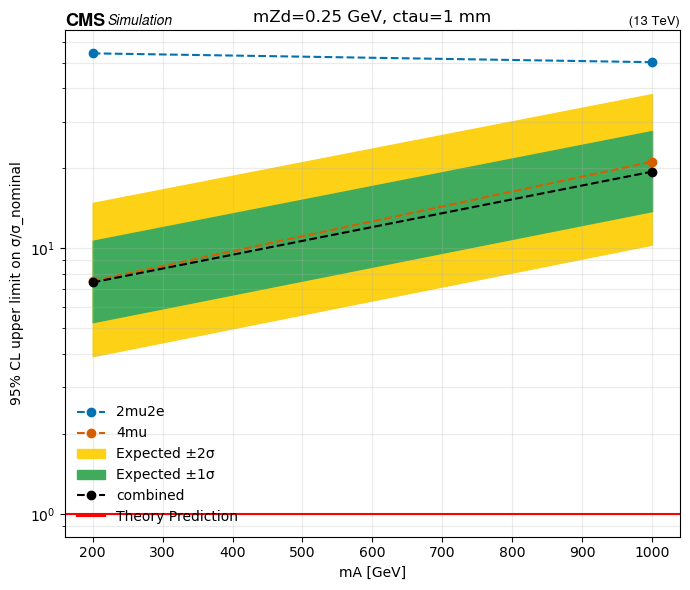

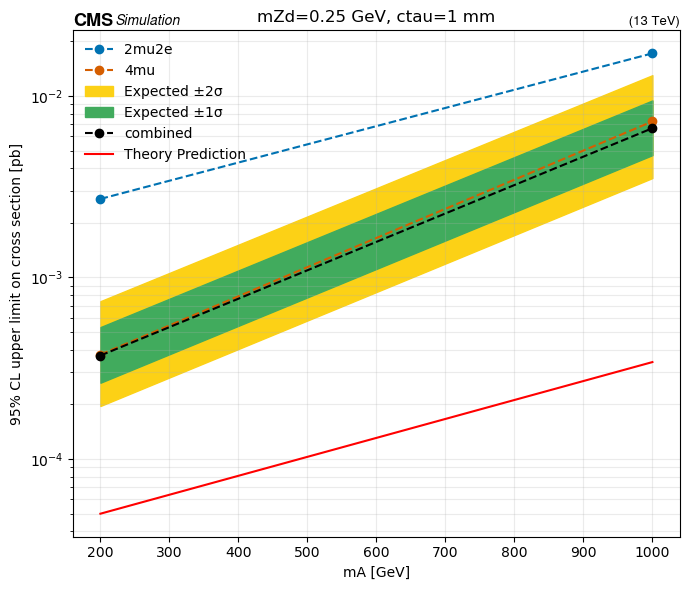

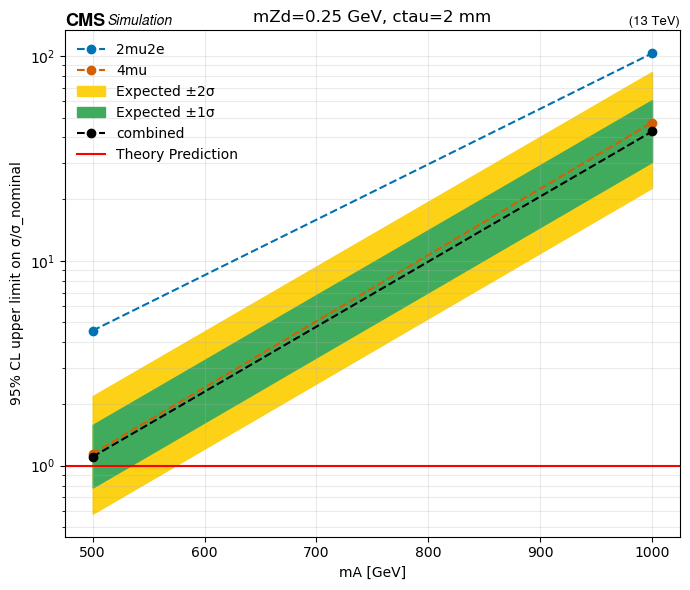

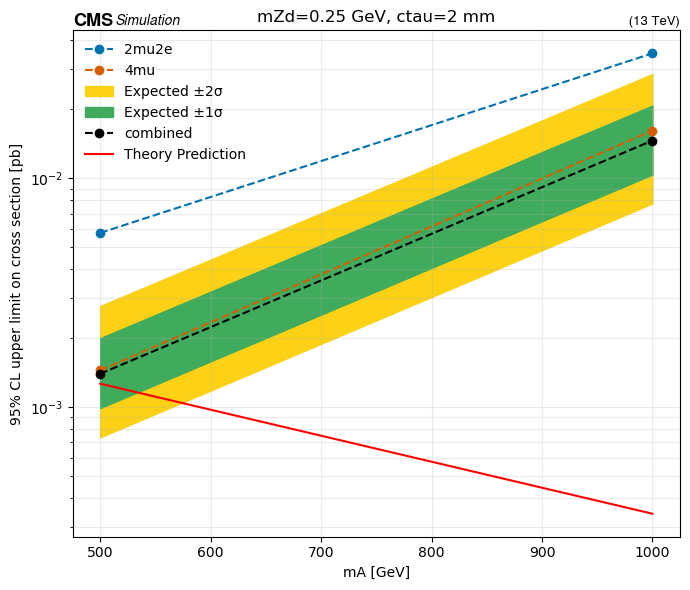

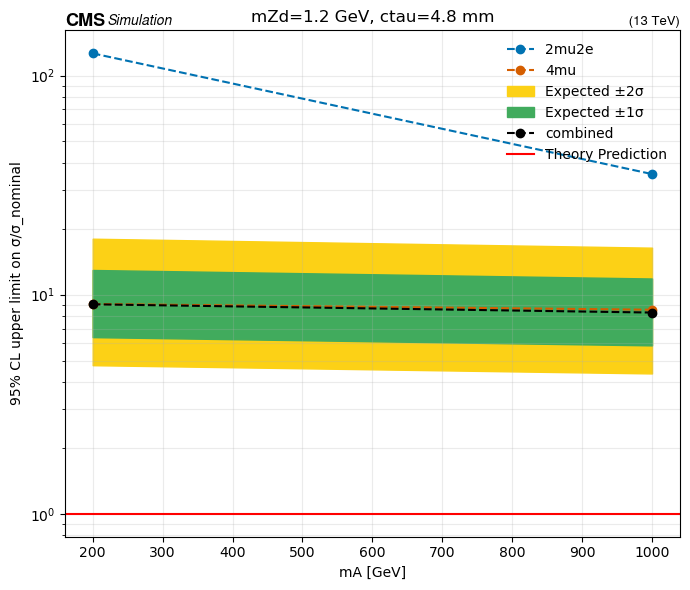

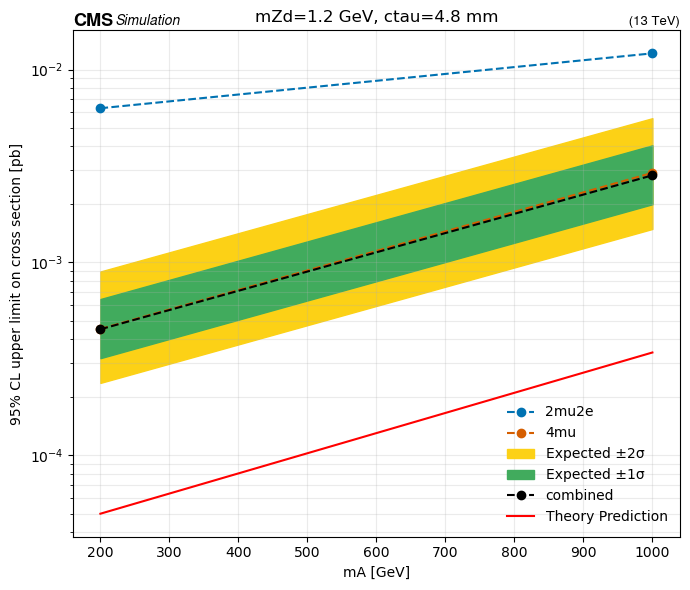

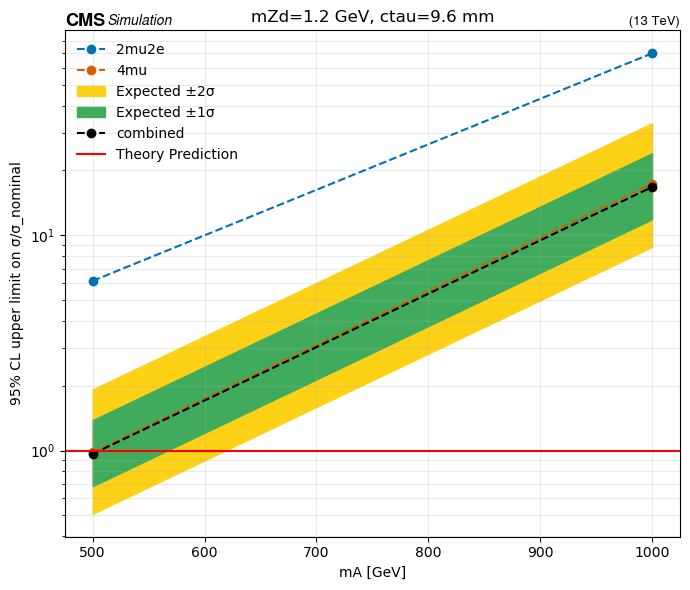

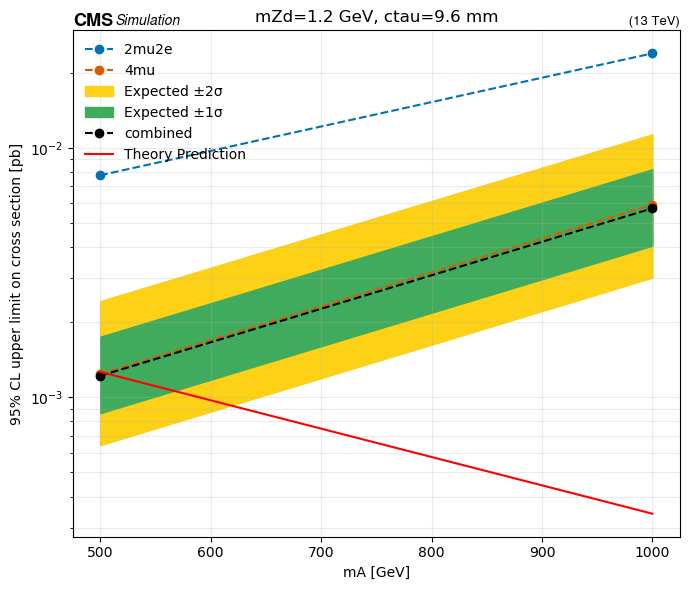

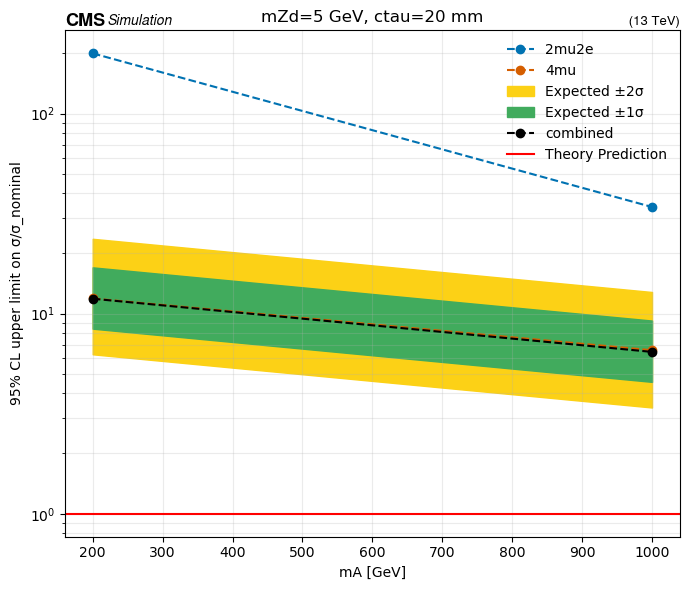

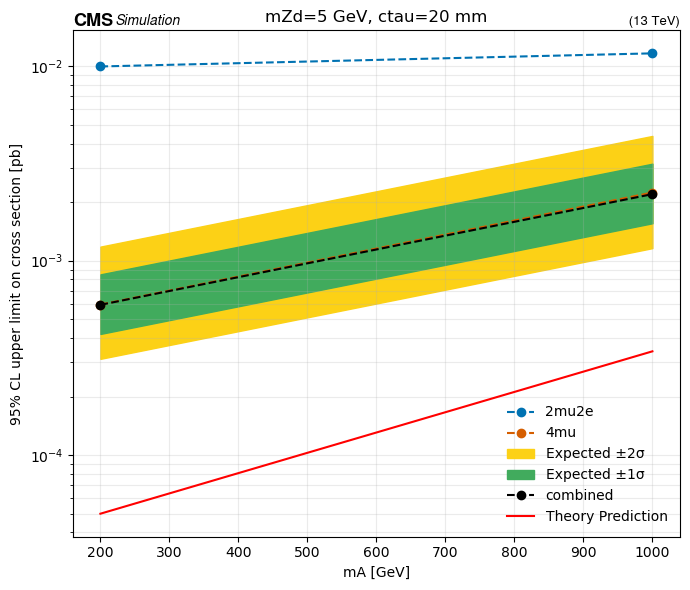

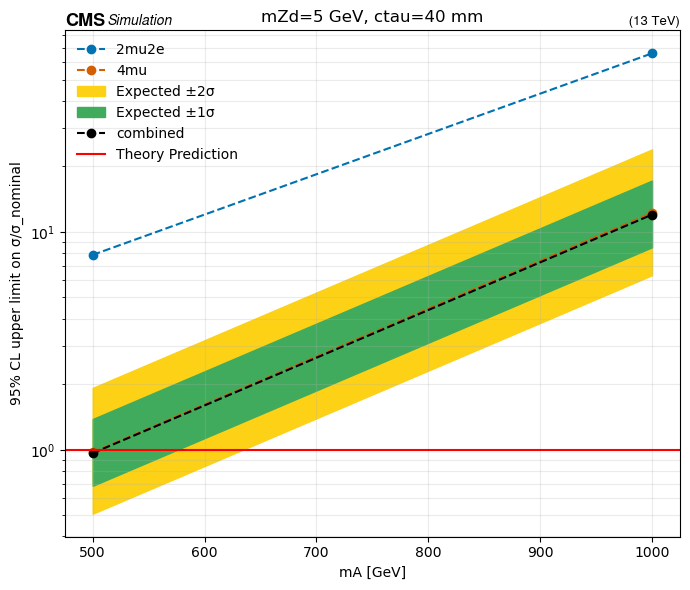

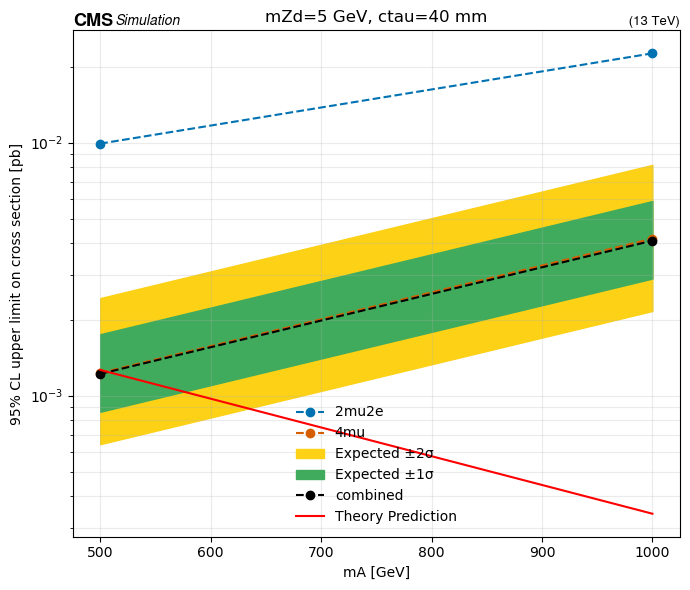

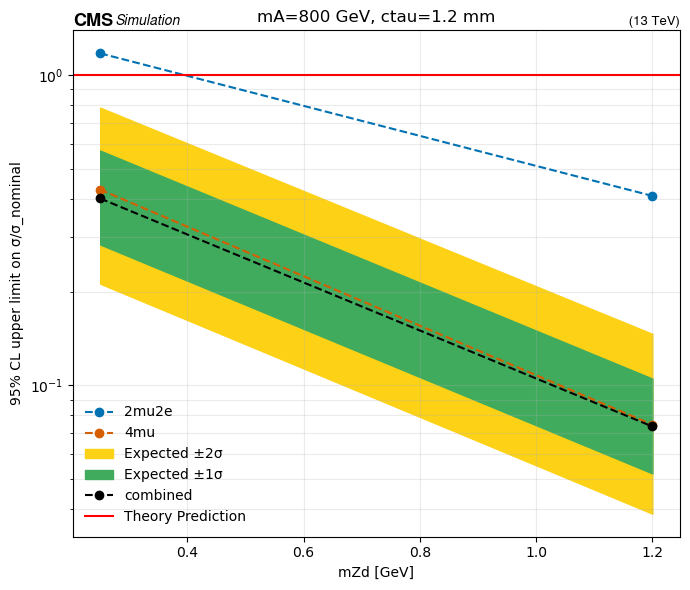

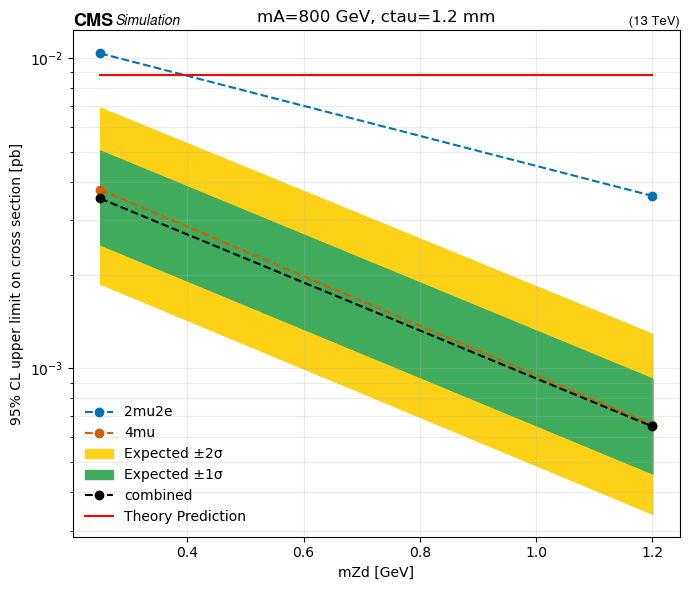

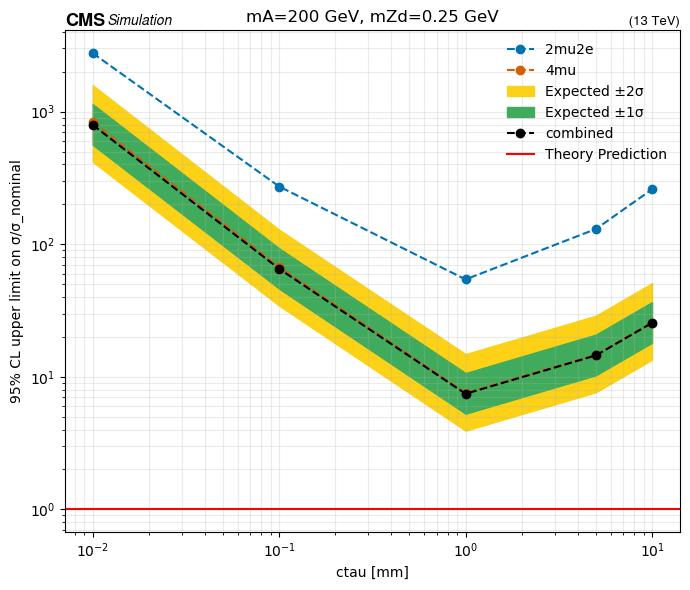

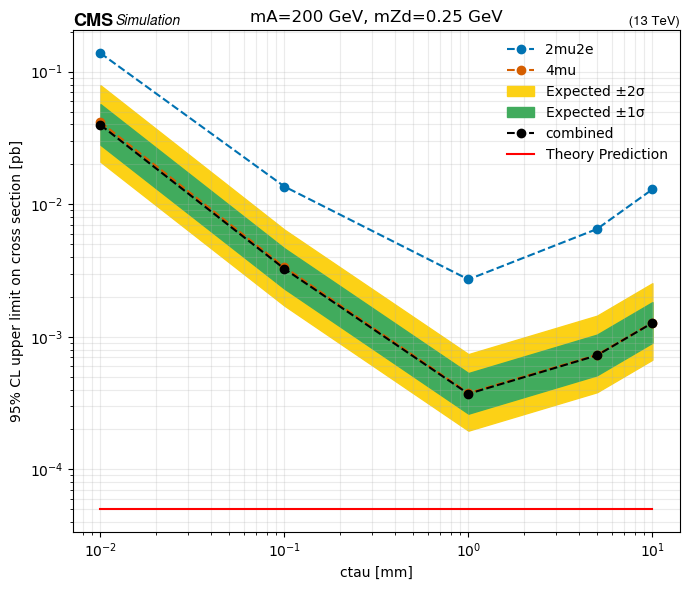

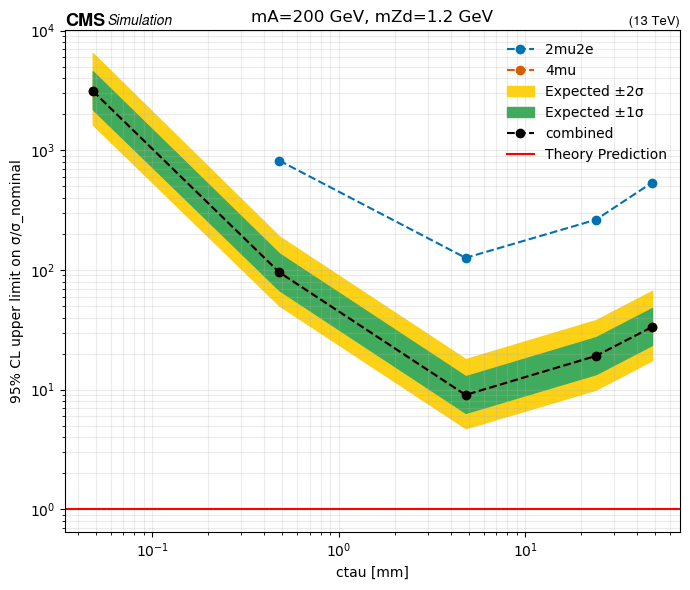

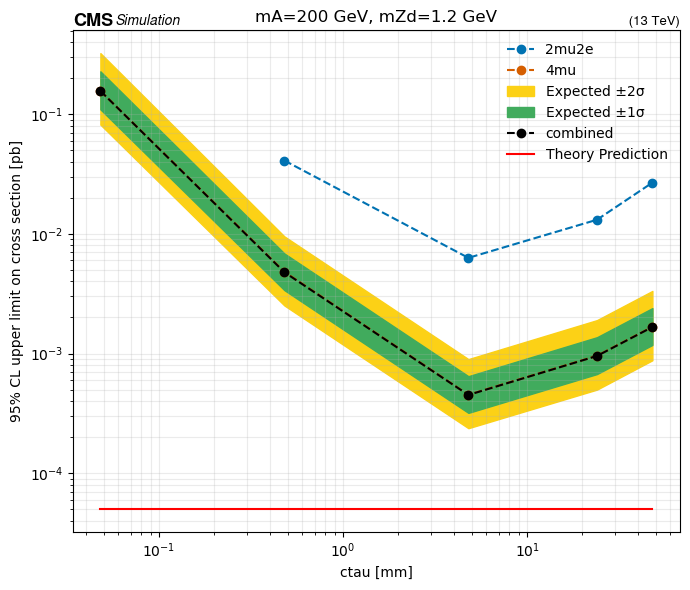

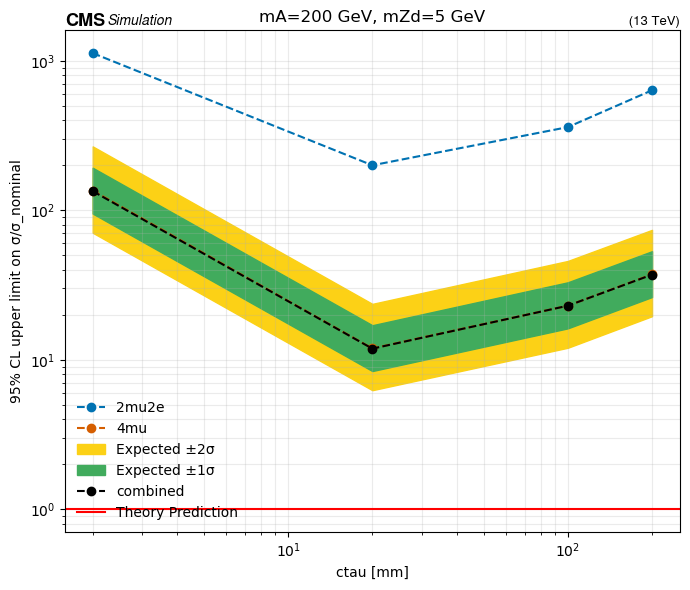

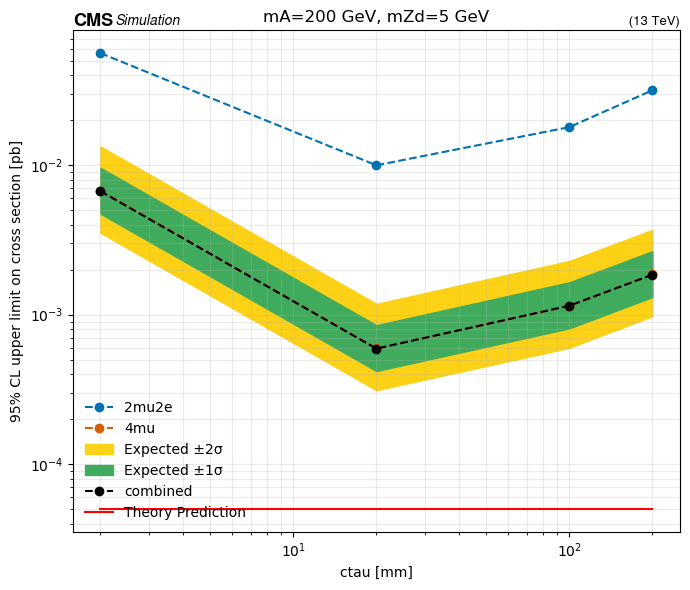

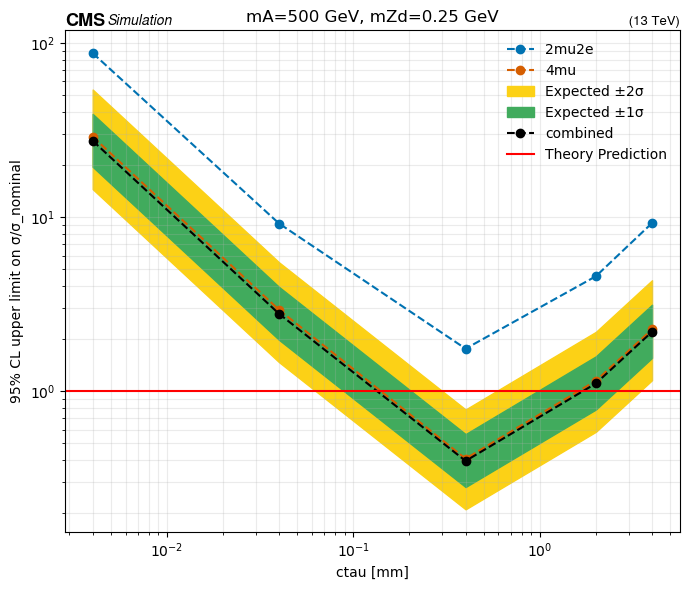

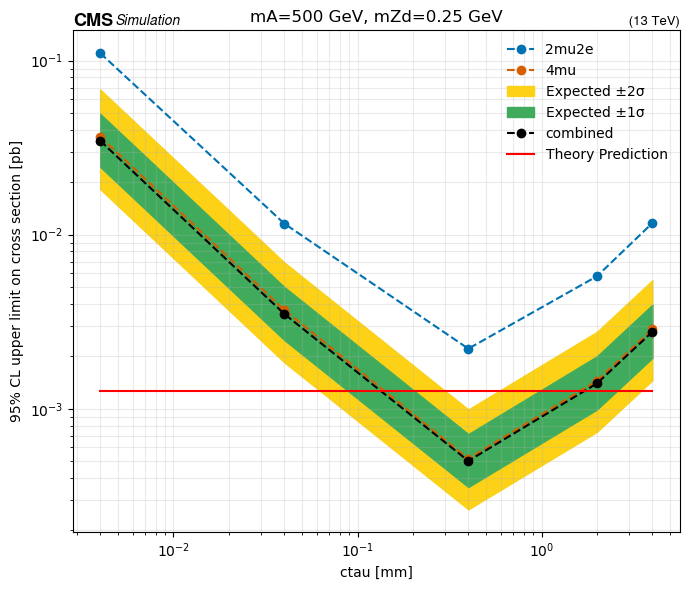

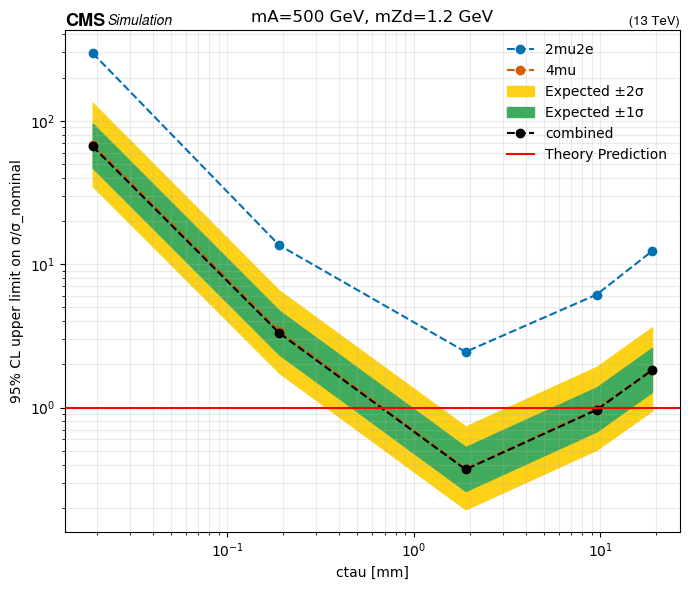

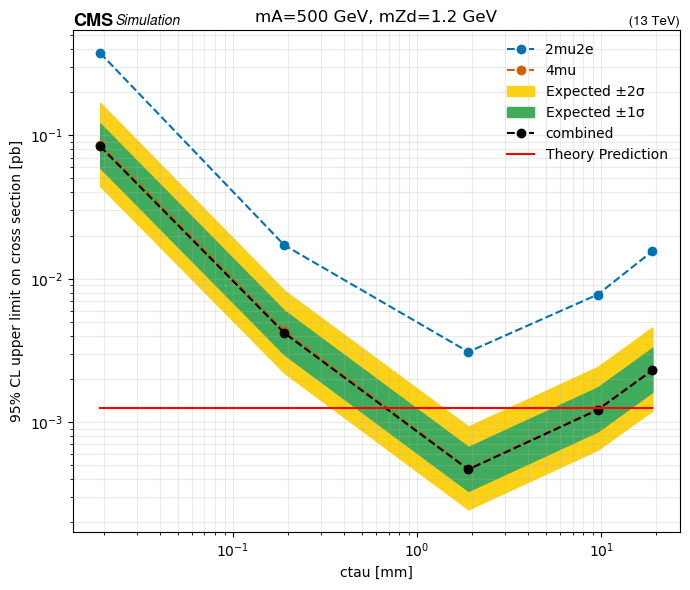

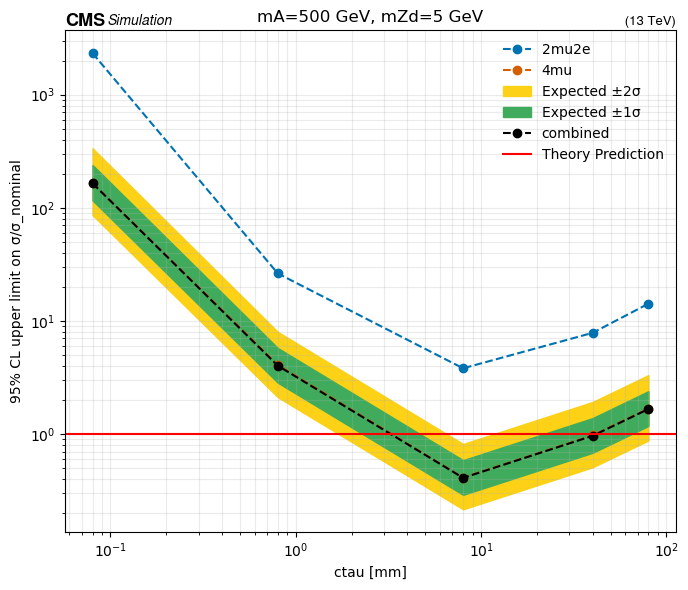

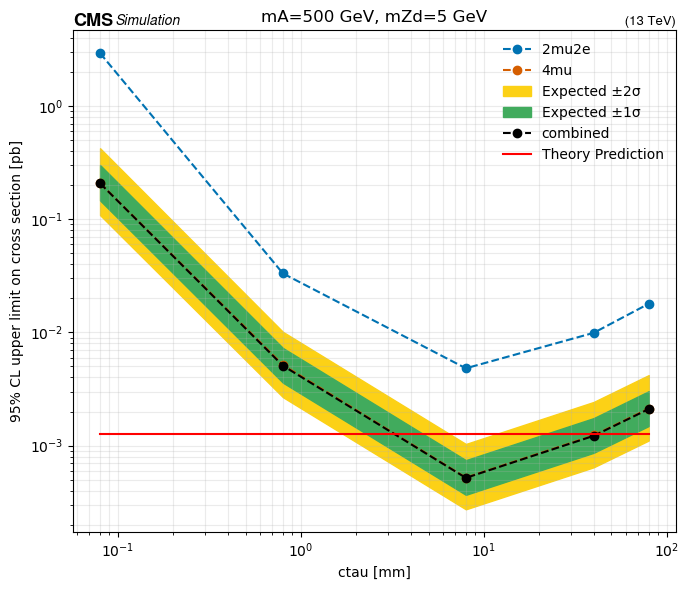

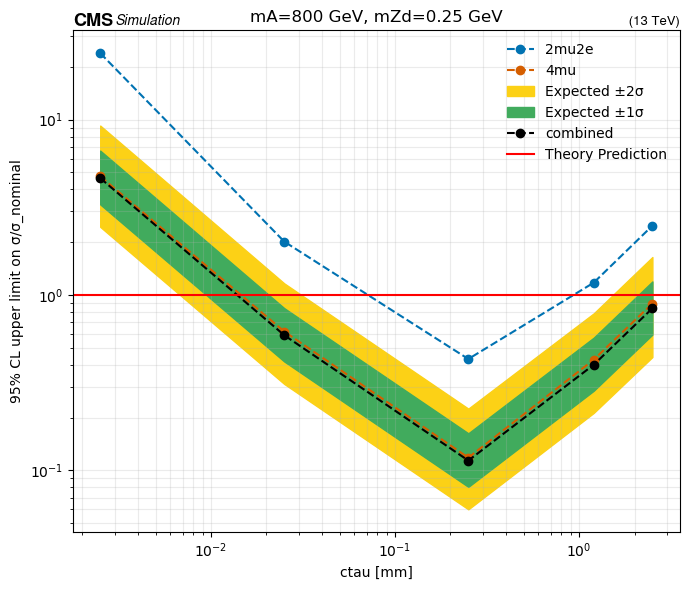

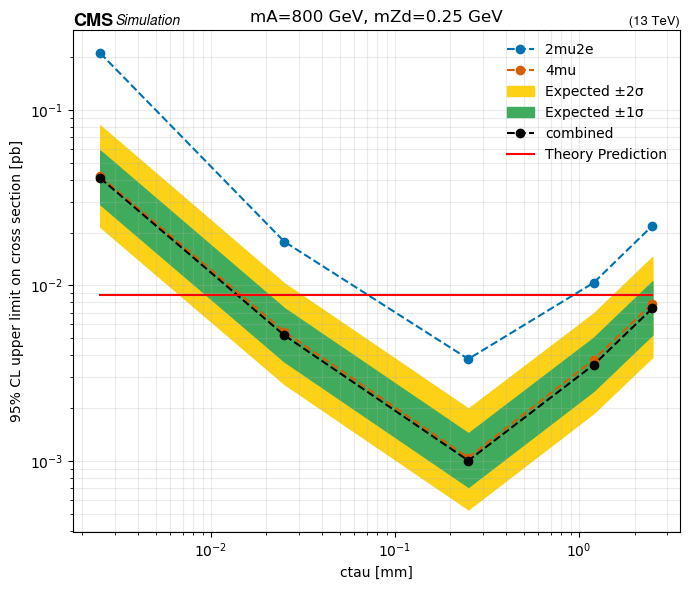

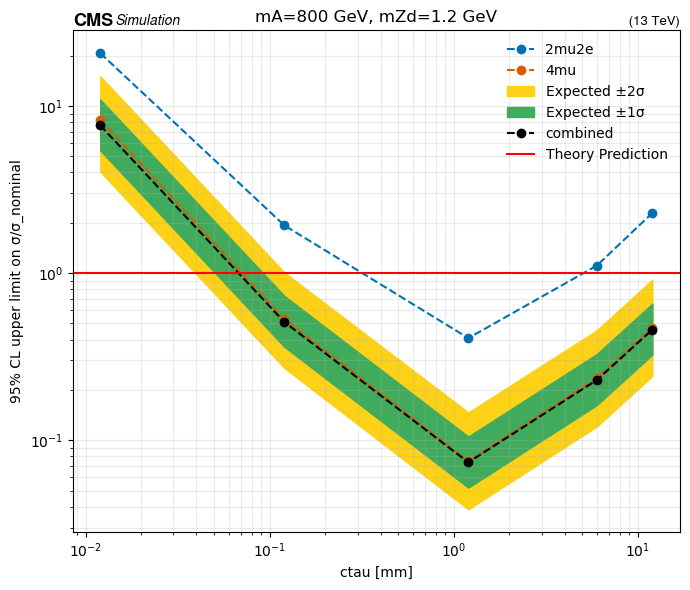

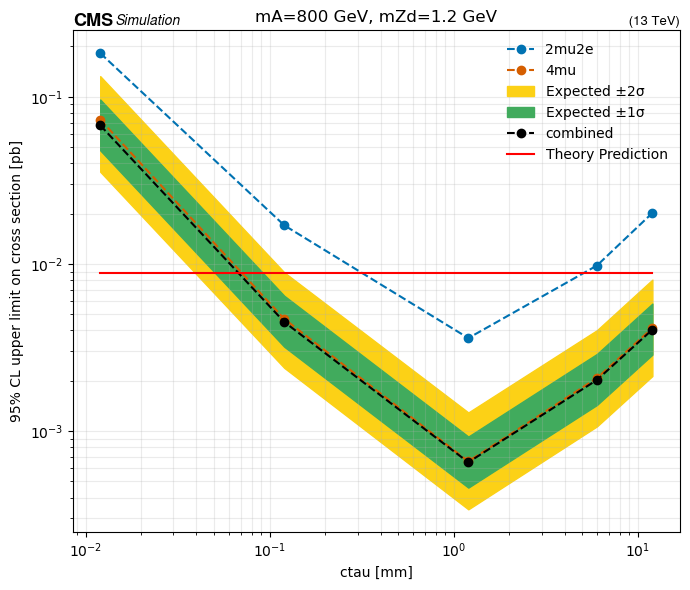

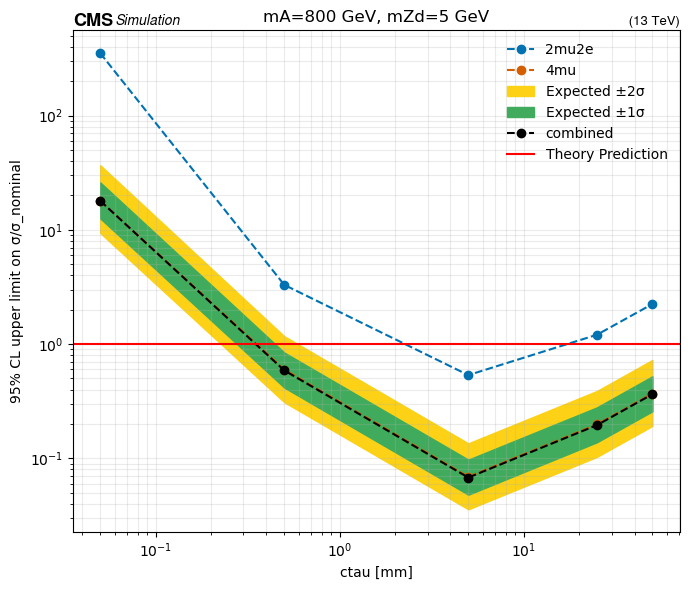

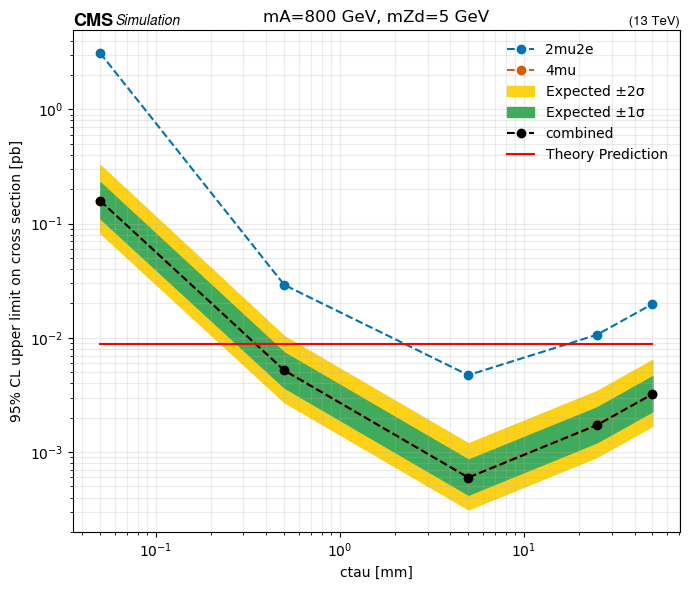

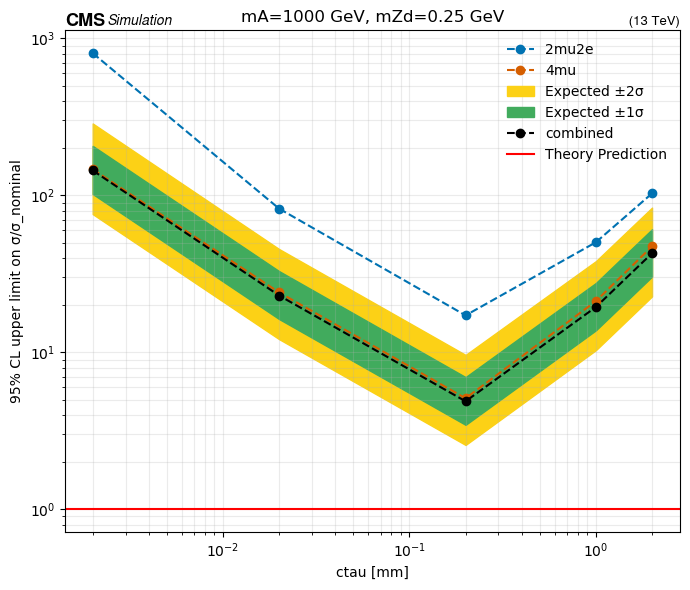

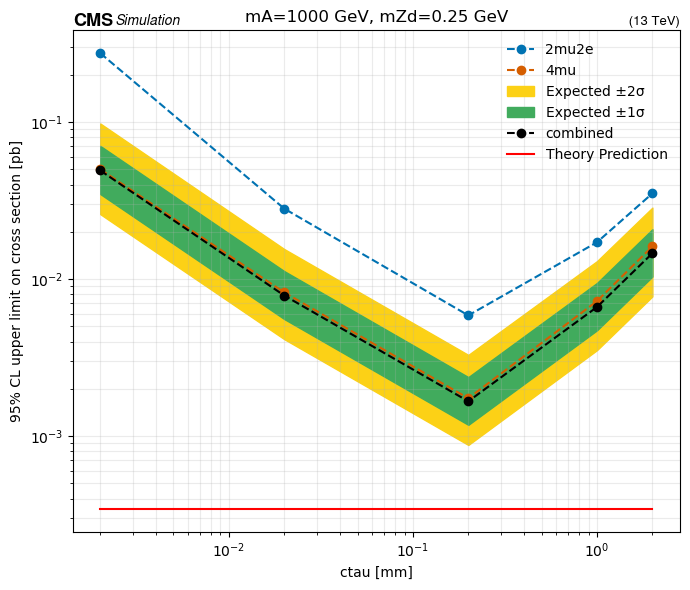

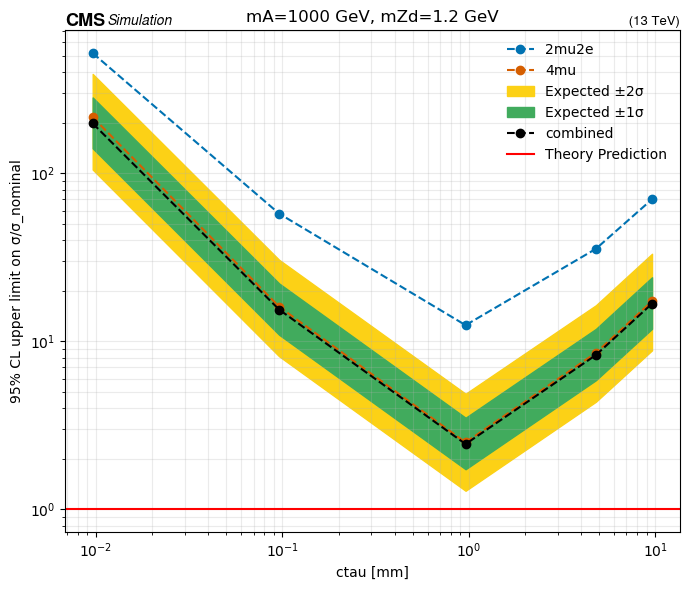

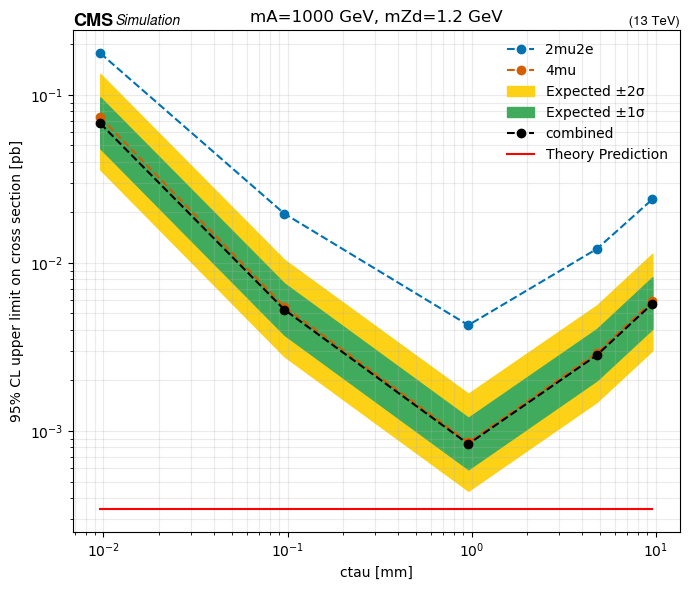

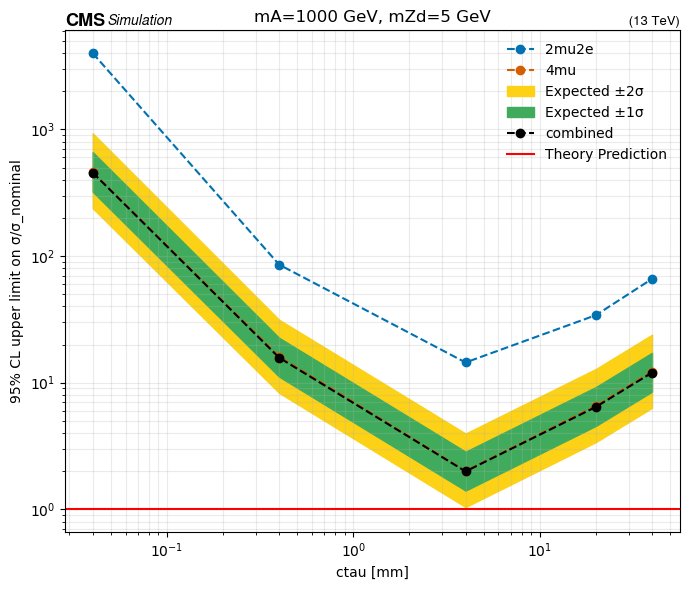

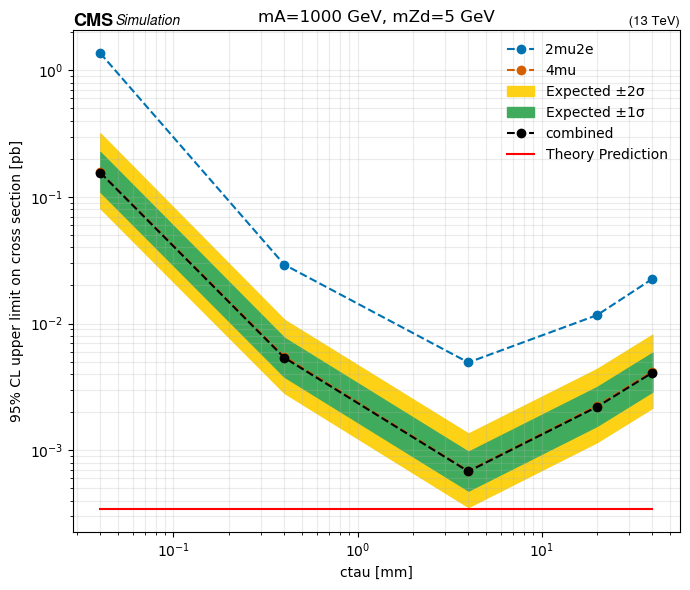

ratio plots: 19 absolute cross-section plots: 19


In [10]:
def plot_scan(frame, x, xlabel, title, path, logx=False):
    fig, ax = plt.subplots(figsize=(7,6))
    colors = {'2mu2e':'#0072B2', '4mu':'#D55E00', 'combined':'black'}
    for channel, color in colors.items():
        selected = frame[frame.channel == channel].sort_values(x)
        if len(selected) < 2: continue
        xv = selected[x].to_numpy(float)
        if channel == 'combined':
            ax.fill_between(xv, selected.exp_m2, selected.exp_p2, color='#FCD116', label='Expected ±2σ')
            ax.fill_between(xv, selected.exp_m1, selected.exp_p1, color='#41AB5D', label='Expected ±1σ')
        ax.plot(xv, selected.exp_median, 'o--', color=color, label=channel)
    if not ax.lines: plt.close(fig); return 0
    ax.axhline(1, color='red', label='Theory Prediction'); ax.set_yscale('log')
    if logx: ax.set_xscale('log')
    ax.set(xlabel=xlabel, ylabel='95% CL upper limit on σ/σ_nominal', title=title)
    ax.grid(True, which='both', alpha=.25); ax.legend(frameon=False); hep.cms.label(data=False, com=13, ax=ax)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show(); plt.close(fig); return 1

def plot_xsec_scan(frame, x, xlabel, title, path, logx=False):
    fig, ax = plt.subplots(figsize=(7,6))
    colors = {'2mu2e':'#0072B2', '4mu':'#D55E00', 'combined':'black'}
    for channel, color in colors.items():
        selected = frame[frame.channel == channel].sort_values(x)
        if len(selected) < 2: continue
        xv = selected[x].to_numpy(float)
        if channel == 'combined':
            ax.fill_between(xv, selected.exp_m2_xsec_pb, selected.exp_p2_xsec_pb, color='#FCD116', label='Expected ±2σ')
            ax.fill_between(xv, selected.exp_m1_xsec_pb, selected.exp_p1_xsec_pb, color='#41AB5D', label='Expected ±1σ')
        ax.plot(xv, selected.exp_median_xsec_pb, 'o--', color=color, label=channel)
    if not ax.lines: plt.close(fig); return 0
    nominal = frame.groupby(x, as_index=False).xsec_nominal_pb.first().sort_values(x)
    ax.plot(nominal[x], nominal.xsec_nominal_pb, color='red', label='Theory Prediction')
    ax.set_yscale('log')
    if logx: ax.set_xscale('log')
    ax.set(xlabel=xlabel, ylabel='95% CL upper limit on cross section [pb]', title=title)
    ax.grid(True, which='both', alpha=.25); ax.legend(frameon=False); hep.cms.label(data=False, com=13, ax=ax)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show(); plt.close(fig); return 1

nplots = 0
nxsec_plots = 0
if len(limits):
    for (mzd,ctau), frame in limits.groupby(['mZd_GeV','ctau_mm']):
        nplots += plot_scan(frame,'mA_GeV','mA [GeV]',f'mZd={mzd:g} GeV, ctau={ctau:g} mm',PLOTS/f'mA_mZd{mzd:g}_ctau{ctau:g}mm.png')
        nxsec_plots += plot_xsec_scan(frame,'mA_GeV','mA [GeV]',f'mZd={mzd:g} GeV, ctau={ctau:g} mm',PLOTS/f'mA_mZd{mzd:g}_ctau{ctau:g}mm_xsec_pb.png')
    for (ma,ctau), frame in limits.groupby(['mA_GeV','ctau_mm']):
        nplots += plot_scan(frame,'mZd_GeV','mZd [GeV]',f'mA={ma:g} GeV, ctau={ctau:g} mm',PLOTS/f'mZd_mA{ma:g}_ctau{ctau:g}mm.png')
        nxsec_plots += plot_xsec_scan(frame,'mZd_GeV','mZd [GeV]',f'mA={ma:g} GeV, ctau={ctau:g} mm',PLOTS/f'mZd_mA{ma:g}_ctau{ctau:g}mm_xsec_pb.png')
    for (ma,mzd), frame in limits.groupby(['mA_GeV','mZd_GeV']):
        nplots += plot_scan(frame,'ctau_mm','ctau [mm]',f'mA={ma:g} GeV, mZd={mzd:g} GeV',PLOTS/f'ctau_mA{ma:g}_mZd{mzd:g}.png',True)
        nxsec_plots += plot_xsec_scan(frame,'ctau_mm','ctau [mm]',f'mA={ma:g} GeV, mZd={mzd:g} GeV',PLOTS/f'ctau_mA{ma:g}_mZd{mzd:g}_xsec_pb.png',True)
print('ratio plots:', nplots, 'absolute cross-section plots:', nxsec_plots)


## Validation and interpretation

1. `mc_background_srA_stats.csv`에서 4mu SR A의 process별 `yield/error/Neff`를 먼저 확인한다.
2. signal grid completeness와 signal SR A low-stat flag를 확인한다.
3. smoke point 세 카드(2mu2e, 4mu, combined)를 실행하고 Combine 로그의 nuisance 구성을 확인한다.
4. 결과가 안정적일 때만 `RUN_SCOPE='full'`로 확장한다.
5. 이 결과는 direct-MC baseline이다. 다음 단계에서는 B/C/D Data control region과 κ constraint를 포함한 simultaneous ABCD likelihood와 비교한다.
